<a href="https://colab.research.google.com/github/morningstareffort/upgraded-garbanzo/blob/master/Copy_of_MNISTExam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MNIST
Using the [MNIST](http://yann.lecun.com/exdb/mnist/) database, we'll train a model that can recognize handwritten digits.

In [2]:
import torch
from torch.nn.modules.loss import CrossEntropyLoss
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

## Let's use the GPU
So you don't have to restart the runtime later in the notebook, let's tell Colab to use the GPU for hardware acceleration now.

Go to Runtime > Change Runtime Type and select GPU, then continue.

In [3]:
# device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device: ", device)

Device:  cuda


In [4]:
# hyperparameters
features = 784 # images are 28x28
hidden_size = 100 # how many neurons to have in our hidden layer
num_labels = 10 # digits from 0-9
num_epochs = 10
batch_size = 100
learning_rate = 0.001

# This data comes straight from PyTorch's Computer Vision library
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor())

# dataloaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False) # no need to shuffle the test set

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.94MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.48MB/s]


torch.Size([100, 1, 28, 28]) torch.Size([100])


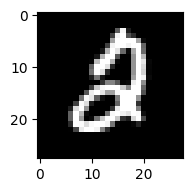

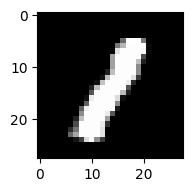

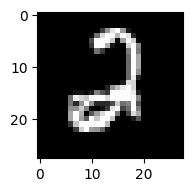

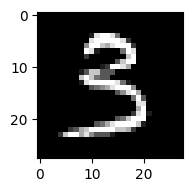

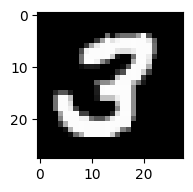

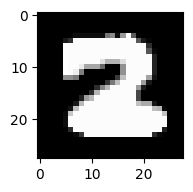

In [5]:
# looking at the data
examples = iter(train_loader)
samples, labels = next(examples)
print(samples.shape, labels.shape)

for i in range(6):
  plt.subplot(2,3,i+1)
  plt.imshow(samples[i][0], cmap='gray')
  plt.show()

In [6]:
class NeuralNet(nn.Module):
  def __init__(self, features, hidden_size, num_labels):
    super(NeuralNet, self).__init__()
    self.l1 = nn.Linear(features, hidden_size) # first layer

    self.relu = nn.ReLU()
    self.l2 = nn.Linear(hidden_size, num_labels) # hidden layer to output
    self.l2 = nn.Linear(hidden_size, num_labels) # hidden layer to output

  def forward(self, x):
    out = self.l1(x)
    out = self.relu(out)
    out = self.l2(out)
    return out

model = NeuralNet(features, hidden_size, num_labels).to(device)

In [7]:
# loss and optimizer
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# training loop
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    images = images.reshape(-1, 28*28).to(device) # reshape turns the 28x28 squares into a single (1,784) vector
    labels = labels.to(device)

    # forward pass
    outputs = model(images)
    loss = loss_function(outputs, labels)

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (i + 1) % 100 == 0:
      print(f'epoch {epoch+1} / {num_epochs}, batch {i+1}/{n_total_steps}, loss = {loss.item():.4f}')
      if(i+1  == n_total_steps):
        print("epoch complete!")

epoch 1 / 10, batch 100/600, loss = 2.3043
epoch 1 / 10, batch 200/600, loss = 2.2609
epoch 1 / 10, batch 300/600, loss = 2.2344
epoch 1 / 10, batch 400/600, loss = 2.2330
epoch 1 / 10, batch 500/600, loss = 2.2117
epoch 1 / 10, batch 600/600, loss = 2.1812
epoch complete!
epoch 2 / 10, batch 100/600, loss = 2.1776
epoch 2 / 10, batch 200/600, loss = 2.1608
epoch 2 / 10, batch 300/600, loss = 2.1220
epoch 2 / 10, batch 400/600, loss = 2.1068
epoch 2 / 10, batch 500/600, loss = 2.0782
epoch 2 / 10, batch 600/600, loss = 2.0845
epoch complete!
epoch 3 / 10, batch 100/600, loss = 2.0837
epoch 3 / 10, batch 200/600, loss = 2.0219
epoch 3 / 10, batch 300/600, loss = 1.9773
epoch 3 / 10, batch 400/600, loss = 1.9743
epoch 3 / 10, batch 500/600, loss = 1.9522
epoch 3 / 10, batch 600/600, loss = 1.9009
epoch complete!
epoch 4 / 10, batch 100/600, loss = 1.8674
epoch 4 / 10, batch 200/600, loss = 1.7839
epoch 4 / 10, batch 300/600, loss = 1.8281
epoch 4 / 10, batch 400/600, loss = 1.8285
epoch 

In [8]:
with torch.no_grad():
      n_correct = 0
      n_samples = 0
      for images, labels in test_loader:
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)
        outputs = model(images).to(device)
        _, predictions = torch.max(outputs, 1) # we don't need the first value returned by torch.max, so discard it via the _
        n_samples += labels.shape[0]
        n_correct += (predictions == labels).sum().item()

      acc = 100.0 * n_correct / n_samples
      print(f'accuracy = {acc}')

accuracy = 82.84
